In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt;
import shutil
import psutil

import numpy as np
import re

import sys
import pyemu
import flopy

sys.path.insert(0,"..")
import herebedragons as hbd

import subprocess

### Create temp directory so we don't break anything

In [2]:
# folder containing original model files
org_d = os.path.join('..', 'input-files')

In [3]:
# specify a template directory (i.e. the PstFrom working folder)
template_ws = os.path.join('..','peterson_template_tran')

In [4]:
# load simulation
sim = flopy.mf6.MFSimulation.load(sim_ws=org_d)
# load flow model
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package riv...
    loading package obs...
    loading package wel...
    loading package chd...
    loading package sto...
    loading package rch...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading packag

### Instantiate PstFrom

Now we can start to construct the PEST(++) interface by instantiating a PstFrom class instance. There are a few things that we need to specify up front:

the folder in which we currently have model files (e.g. tmp_d). PstFrom will copy all the files from this directory into a new "template" folder.

template folder: this is a folder in which the PEST dataset will be constructed - this folder will hold the model files plus all of the files needed to run PEST(++). This folder/dataset will form the template for subsequent deployment of PEST(++).

longnames: for backwards compatibility with PEST and PEST_HP (i.e. non-PEST++ versions), which have upper limits to parameter/observation names (PEST++ does not). Setting this value to False is only recommended if required.

Whether the model is zero based or not.

(optional) the spatial reference, as previously discussed. This is only required if using pyEMU to define parameter spatial correlation. Alternatively, you can define these yourself or use utilities available in the PEST-suite.

In [5]:
sr = pyemu.helpers.SpatialReference.from_namfile(
        os.path.join(org_d, "peterson_flow.nam"),
        delr=gwf.dis.delr.array, delc=gwf.dis.delc.array)

   could not remove start_datetime


In [6]:
start_datetime="1-1-1970"
# instantiate PstFrom
pf = pyemu.utils.PstFrom(original_d=org_d, # where the model is stored
                            new_d=template_ws, # the PEST template folder
                            remove_existing=True, # ensures a clean start
                            longnames=True, # set False if using PEST/PEST_HP
                            spatial_reference=sr, #the spatial reference we generated earlier
                            zero_based=False, # does the MODEL use zero based indices? For example, MODFLOW does NOT
                            start_datetime=start_datetime, # required when specifying temporal correlation between parameters
                            echo=False) # to stop PstFrom from writting lots of infromation to the notebook; experiment by setting it as True to see the difference; usefull for troubleshooting
     

## Sanitize Outputs:

weird modflow bug: 3 digit scientific notation in output files doesn't put the E
- `1.104572-123` instead of `1.104572-E123`

Numpy, pandas, flopy, etc, REALLY don't like when this happens, so we need to fix that by running the following cell:

In [7]:
# Read the CSV
pfos = pd.read_csv('../peterson_template_tran/output-files/pfos_obs.csv', dtype=str)  # Read as string to avoid automatic misinterpretation
pfoa = pd.read_csv('../peterson_template_tran/output-files/pfoa_obs.csv', dtype=str) 
pfhxs = pd.read_csv('../peterson_template_tran/output-files/pfhxs_obs.csv', dtype=str)

In [8]:
# Read the CSV
pfos = pd.read_csv('../peterson_template_tran/output-files/pfos_obs.csv', dtype=str)  # Read as string to avoid automatic misinterpretation
pfoa = pd.read_csv('../peterson_template_tran/output-files/pfoa_obs.csv', dtype=str) 
pfhxs = pd.read_csv('../peterson_template_tran/output-files/pfhxs_obs.csv', dtype=str) 

# Function to fix scientific notation issues
def fix_scientific_notation(value):
    if isinstance(value, str):
        return re.sub(r'(\d+)-(\d+)', r'\1e-\2', value)
    return value  # Return unchanged if not a string

# Apply the fix to all columns
pfos = pfos.map(fix_scientific_notation)
pfoa = pfoa.map(fix_scientific_notation)
pfhxs = pfhxs.map(fix_scientific_notation)

# Convert columns back to numeric where possible
pfos= pfos.apply(pd.to_numeric)
pfoa= pfoa.apply(pd.to_numeric)
pfhxs= pfhxs.apply(pd.to_numeric)

# Save the fixed CSV
pfos.to_csv('../peterson_template_tran/output-files/pfos_obs.csv', index=False)
pfoa.to_csv('../peterson_template_tran/output-files/pfoa_obs.csv', index=False)
pfhxs.to_csv('../peterson_template_tran/output-files/pfhxs_obs.csv', index=False)

### Write Instructional file from observations

In [9]:
# Read in output concentrations
pfos_df = pfos
pfoa_df= pfoa
pfhxs_df= pfhxs

In [10]:
pfos_df

,time,BRD_6,11960_OPR_2,12425_OPR_1,DLE,GLD_3,ING_2,IRIS_3,WELL-1,WELL-3,...,PETER-T05-MW001,PETER-T07-001,PETER-T07-003,PETER-T07-004,PETER-T13-003,PETER-T13-004,PETER-T13-MW001,PETER-T13-MW003,PETER-T13-MW004,PETER-T13-MW006
0,59.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,89.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,274.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,304.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,365.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,18139.0,0.001215,1.277355e-21,5.701010e-22,4.412539e-16,4.067710e-24,3.537732e-122,4.800024e-16,3.173851e-16,1.732956e-17,...,0.001130,0.000985,0.001098,0.001034,0.000942,0.000948,0.001149,0.000964,0.000958,0.000557
442,18169.0,0.001230,1.247475e-21,5.583305e-22,4.447577e-16,3.982305e-24,4.048115e-122,4.840537e-16,3.200064e-16,1.724469e-17,...,0.001134,0.000989,0.001101,0.001038,0.000954,0.000953,0.001158,0.000976,0.000963,0.000562
443,18200.0,0.001244,1.215883e-21,5.458438e-22,4.480547e-16,3.892339e-24,4.643681e-122,4.880750e-16,3.223831e-16,1.708896e-17,...,0.001139,0.000992,0.001104,0.001043,0.000963,0.000958,0.001164,0.000986,0.000968,0.000567
444,18230.0,0.001258,1.186367e-21,5.341453e-22,4.516025e-16,3.807346e-24,5.298881e-122,4.922427e-16,3.249144e-16,1.696235e-17,...,0.001143,0.000996,0.001107,0.001047,0.000973,0.000963,0.001169,0.000996,0.000972,0.000572


In [11]:
#Read in real concentrations for each solute
pfos_obs= pd.read_csv('../input-files/data-files/tran-PFOS-observations.csv')
pfos_obs.iloc[:, 1:] = pfos_obs.iloc[:, 1:] / 1e6
pfos_obs.head()

,time,11960_OPR_2,12425_OPR_1,BRD_6,C2,C36,DLE,FV4,GLD_3,IRIS_3,...,S4,S7,S9,W12,W7,W8,W9,WELL-1,WELL-3,WELL-4
0,16925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#Read in real concentrations for each solute
pfoa_obs= pd.read_csv('../input-files/data-files/tran-PFOA-observations.csv')
pfoa_obs.iloc[:, 1:] = pfoa_obs.iloc[:, 1:] / 1e6
pfoa_obs.head()

,time,11960_OPR_2,12425_OPR_1,BRD_6,C2,C36,DLE,FV4,GLD_3,IRIS_3,...,S4,S7,S9,W12,W7,W8,W9,WELL-1,WELL-3,WELL-4
0,16925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#Read in real concentrations for each solute
pfhxs_obs= pd.read_csv('../input-files/data-files/tran-PFHxS-observations.csv')
pfhxs_obs.iloc[:, 1:] = pfhxs_obs.iloc[:, 1:] / 1e6
pfhxs_obs.head()

,time,11960_OPR_2,12425_OPR_1,BRD_6,C2,C36,DLE,FV4,GLD_3,IRIS_3,...,S4,S7,S9,W12,W7,W8,W9,WELL-1,WELL-3,WELL-4
0,16925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Function to find the closest unique time in mod for a given time in obs
def find_closest_unique_time(time, mod_times, used_times):
    available_times = [t for t in mod_times if t not in used_times]
    if not available_times:  # If all times are used, allow duplicates (fallback)
        return min(mod_times, key=lambda x: abs(x - time))
    
    closest_time = min(available_times, key=lambda x: abs(x - time))
    used_times.add(closest_time)  # Mark this time as used
    return closest_time

# Convert mod time columns to lists for faster lookup
mod_times_pfos = pfos_df['time'].tolist()
mod_times_pfoa = pfoa_df['time'].tolist()
mod_times_pfhxs = pfhxs_df['time'].tolist()

# Track used times to avoid duplicates
used_times_pfos = set()
used_times_pfoa = set()
used_times_pfhxs = set()

# Apply function while ensuring uniqueness
pfos_obs['time'] = pfos_obs['time'].apply(lambda x: find_closest_unique_time(x, mod_times_pfos, used_times_pfos))
pfoa_obs['time'] = pfoa_obs['time'].apply(lambda x: find_closest_unique_time(x, mod_times_pfoa, used_times_pfoa))
pfhxs_obs['time'] = pfhxs_obs['time'].apply(lambda x: find_closest_unique_time(x, mod_times_pfhxs, used_times_pfhxs))

# Optional: Ensure no duplicates remain
pfos_obs.drop_duplicates(subset=['time'], inplace=True)
pfoa_obs.drop_duplicates(subset=['time'], inplace=True)
pfhxs_obs.drop_duplicates(subset=['time'], inplace=True)


In [15]:
#make placeholder data frame same size as output file
pfos_shape=pfos_df
pfos_shape.iloc[:, 1:] = -999

filtered_pfos = pfos_obs.where(pfos_obs.notna(), other=-999).replace(0, -999)
filtered_pfos = filtered_pfos[filtered_pfos['time'] != -999]

# Set 'time' as the index to facilitate replacement
pfos_shape.set_index("time", inplace=True)
filtered_pfos.set_index("time", inplace=True)

# Update pfos_shape with matching times from filtered_pfos
pfos_shape.update(filtered_pfos)

# Reset the index back
pfos_shape.reset_index(inplace=True)
filtered_pfos= pfos_shape
filtered_pfos

,time,BRD_6,11960_OPR_2,12425_OPR_1,DLE,GLD_3,ING_2,IRIS_3,WELL-1,WELL-3,...,PETER-T05-MW001,PETER-T07-001,PETER-T07-003,PETER-T07-004,PETER-T13-003,PETER-T13-004,PETER-T13-MW001,PETER-T13-MW003,PETER-T13-MW004,PETER-T13-MW006
0,59.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,89.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,274.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,304.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,365.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,18139.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
442,18169.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
443,18200.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
444,18230.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [16]:
#make placeholder data frame same size as output file
pfoa_shape=pfoa_df
pfoa_shape.iloc[:, 1:] = -999

filtered_pfoa = pfoa_obs.where(pfoa_obs.notna(), other=-999).replace(0, -999)
filtered_pfoa = filtered_pfoa[filtered_pfoa['time'] != -999]

# Set 'time' as the index to facilitate replacement
pfoa_shape.set_index("time", inplace=True)
filtered_pfoa.set_index("time", inplace=True)

# Update pfos_shape with matching times from filtered_pfos
pfoa_shape.update(filtered_pfoa)

# Reset the index back
pfoa_shape.reset_index(inplace=True)
filtered_pfoa= pfoa_shape
filtered_pfoa

,time,BRD_6,11960_OPR_2,12425_OPR_1,DLE,GLD_3,ING_2,IRIS_3,WELL-1,WELL-3,...,PETER-T05-MW001,PETER-T07-001,PETER-T07-003,PETER-T07-004,PETER-T13-003,PETER-T13-004,PETER-T13-MW001,PETER-T13-MW003,PETER-T13-MW004,PETER-T13-MW006
0,59.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,89.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,274.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,304.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,365.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,18139.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
442,18169.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
443,18200.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
444,18230.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [17]:
#make placeholder data frame same size as output file
pfhxs_shape=pfhxs_df
pfhxs_shape.iloc[:, 1:] = -999

filtered_pfhxs = pfhxs_obs.where(pfhxs_obs.notna(), other=-999).replace(0, -999)
filtered_pfhxs = filtered_pfhxs[filtered_pfhxs['time'] != -999]

# Set 'time' as the index to facilitate replacement
pfhxs_shape.set_index("time", inplace=True)
filtered_pfhxs.set_index("time", inplace=True)

# Update pfos_shape with matching times from filtered_pfos
pfhxs_shape.update(filtered_pfhxs)

# Reset the index back
pfhxs_shape.reset_index(inplace=True)
filtered_pfhxs= pfhxs_shape
filtered_pfhxs

,time,BRD_6,11960_OPR_2,12425_OPR_1,DLE,GLD_3,ING_2,IRIS_3,WELL-1,WELL-3,...,PETER-T05-MW001,PETER-T07-001,PETER-T07-003,PETER-T07-004,PETER-T13-003,PETER-T13-004,PETER-T13-MW001,PETER-T13-MW003,PETER-T13-MW004,PETER-T13-MW006
0,59.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,89.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,274.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,304.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,365.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,18139.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
442,18169.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
443,18200.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
444,18230.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [18]:
filtered_pfos.set_index('time', inplace=True)
filtered_pfoa.set_index('time', inplace=True)
filtered_pfhxs.set_index('time', inplace=True)

In [19]:
pfos_obs.set_index('time', inplace=True)
pfoa_obs.set_index('time', inplace=True)
pfhxs_obs.set_index('time', inplace=True)

In [20]:
# **Reshape obs_df into long format**
obs_long_pfos = filtered_pfos.stack().reset_index()
obs_long_pfos.columns = ["time", "well", "value"]  # "value" column holds observed heads
obs_long_pfos

,time,well,value
0,59.0,BRD_6,-999.0
1,59.0,11960_OPR_2,-999.0
2,59.0,12425_OPR_1,-999.0
3,59.0,DLE,-999.0
4,59.0,GLD_3,-999.0
...,...,...,...
29877,18262.0,PETER-T13-004,-999.0
29878,18262.0,PETER-T13-MW001,-999.0
29879,18262.0,PETER-T13-MW003,-999.0
29880,18262.0,PETER-T13-MW004,-999.0


In [21]:
# **Reshape obs_df into long format**
obs_long_pfoa = filtered_pfoa.stack().reset_index()
obs_long_pfoa.columns = ["time", "well", "value"]  # "value" column holds observed heads
obs_long_pfoa

,time,well,value
0,59.0,BRD_6,-999.0
1,59.0,11960_OPR_2,-999.0
2,59.0,12425_OPR_1,-999.0
3,59.0,DLE,-999.0
4,59.0,GLD_3,-999.0
...,...,...,...
29877,18262.0,PETER-T13-004,-999.0
29878,18262.0,PETER-T13-MW001,-999.0
29879,18262.0,PETER-T13-MW003,-999.0
29880,18262.0,PETER-T13-MW004,-999.0


In [22]:
# **Reshape obs_df into long format**
obs_long_pfhxs = filtered_pfhxs.stack().reset_index()
obs_long_pfhxs.columns = ["time", "well", "value"]  # "value" column holds observed heads
obs_long_pfhxs

,time,well,value
0,59.0,BRD_6,-999.0
1,59.0,11960_OPR_2,-999.0
2,59.0,12425_OPR_1,-999.0
3,59.0,DLE,-999.0
4,59.0,GLD_3,-999.0
...,...,...,...
29877,18262.0,PETER-T13-004,-999.0
29878,18262.0,PETER-T13-MW001,-999.0
29879,18262.0,PETER-T13-MW003,-999.0
29880,18262.0,PETER-T13-MW004,-999.0


In [23]:
ins_lines = ["pif ~", "l1"]  # PEST instruction file header, adding "l1" on the second line

# **Group by time and format each time step correctly**
for time, group in obs_long_pfos.groupby("time"):
    ins_line = "l1"  # Read one line
    for well, value in zip(group["well"], group["value"]):  
        if value == -999:
            ins_line += f" ~,~ !dum! "
        else:
            ins_line += f" ~,~ !{well}_{time}_pfos! "  # Add commas after each observation
    ins_lines.append(ins_line.strip(", "))  # Remove trailing comma after the last well

    # Write the .INS file
with open("../peterson_template_tran/pfos.csv.ins", "w", encoding='utf-8') as f:
    f.write("\n".join(ins_lines))

In [24]:
ins_lines = ["pif ~", "l1"]  # PEST instruction file header, adding "l1" on the second line

# **Group by time and format each time step correctly**
for time, group in obs_long_pfoa.groupby("time"):
    ins_line = "l1"  # Read one line
    for well, value in zip(group["well"], group["value"]):  
        if value == -999:
            ins_line += f" ~,~ !dum! "
        else:
            ins_line += f" ~,~ !{well}_{time}_pfoa! "  # Add commas after each observation
    ins_lines.append(ins_line.strip(", "))  # Remove trailing comma after the last well

    # Write the .INS file
with open("../peterson_template_tran/pfoa.csv.ins", "w", encoding='utf-8') as f:
    f.write("\n".join(ins_lines))

In [25]:
ins_lines = ["pif ~", "l1"]  # PEST instruction file header, adding "l1" on the second line

# **Group by time and format each time step correctly**
for time, group in obs_long_pfhxs.groupby("time"):
    ins_line = "l1"  # Read one line
    for well, value in zip(group["well"], group["value"]):  
        if value == -999:
            ins_line += f" ~,~ !dum! "
        else:
            ins_line += f" ~,~ !{well}_{time}_pfhxs! "  # Add commas after each observation
    ins_lines.append(ins_line.strip(", "))  # Remove trailing comma after the last well

    # Write the .INS file
with open("../peterson_template_tran/pfhxs.csv.ins", "w", encoding='utf-8') as f:
    f.write("\n".join(ins_lines))

In [26]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['pfhxs.csv.ins', 'pfoa.csv.ins', 'pfos.csv.ins']

### Write External INS .csv files to reference in PEST control file

In [27]:
ins_data = {
    'pest_file': ['pfos.csv.ins','pfoa.csv.ins','pfhxs.csv.ins'],
    'model_file': ['output-files/pfos_obs.csv','output-files/pfoa_obs.csv','output-files/pfhxs_obs.csv'],
}
ins_data=pd.DataFrame(ins_data)

In [28]:
ins_data=ins_data.astype(str)
ins_data.to_csv('../peterson_template_tran/peterson_tran.insfile_data.csv', index=False)

### Write External observation .csv files to reference in PEST control file

In [29]:
obs_long_pfos = obs_long_pfos[obs_long_pfos['value'] != -999]
obs_long_pfoa = obs_long_pfoa[obs_long_pfoa['value'] != -999]
obs_long_pfhxs = obs_long_pfhxs[obs_long_pfhxs['value'] != -999]

In [30]:
# Initialize an empty list to store the formatted rows for the new DataFrame
obs_data_pfos = []

# Group by the 'time' column to match the instruction file format
for time, group in obs_long_pfos.groupby("time"):
    for _, row in group.iterrows():
        # Construct a new row for each observation with the desired columns
        new_row = {
            "obsnme": f"{row['well']}_{time}_pfos",  # Observation name: well_name_time
            "obsval": row["value"],             # Observation value: the value in the 'value' column
            "weight": 1 /row["value"],          # Observation weight: 1/concentration
            "obgnme": "cnc"                     # Observation group: always 'cnc'
        }
        obs_data_pfos.append(new_row)

# Create the new DataFrame from the list of formatted rows
obs_data_df_pfos = pd.DataFrame(obs_data_pfos)

In [31]:
obs_data_df_pfos=obs_data_df_pfos.astype(str)
obs_data_df_pfos.to_csv('../peterson_template_tran/peterson_pfos.obs_data.csv', index=False)

In [32]:
# Initialize an empty list to store the formatted rows for the new DataFrame
obs_data_pfoa = []

# Group by the 'time' column to match the instruction file format
for time, group in obs_long_pfoa.groupby("time"):
    for _, row in group.iterrows():
        # Construct a new row for each observation with the desired columns
        new_row = {
            "obsnme": f"{row['well']}_{time}_pfoa",  # Observation name: well_name_time
            "obsval": row["value"],             # Observation value: the value in the 'value' column
            "weight": 1/row["value"],           # Observation weight: always 1
            "obgnme": "cnc"                     # Observation group: always 'cnc'
        }
        obs_data_pfoa.append(new_row)

# Create the new DataFrame from the list of formatted rows
obs_data_df_pfoa = pd.DataFrame(obs_data_pfoa)

In [33]:
obs_data_df_pfoa=obs_data_df_pfoa.astype(str)
obs_data_df_pfoa.to_csv('../peterson_template_tran/peterson_pfoa.obs_data.csv', index=False)

In [34]:
# Initialize an empty list to store the formatted rows for the new DataFrame
obs_data_pfhxs = []

# Group by the 'time' column to match the instruction file format
for time, group in obs_long_pfhxs.groupby("time"):
    for _, row in group.iterrows():
        # Construct a new row for each observation with the desired columns
        new_row = {
            "obsnme": f"{row['well']}_{time}_pfhxs",  # Observation name: well_name_time
            "obsval": row["value"],             # Observation value: the value in the 'value' column
            "weight": 1 /row["value"],          # Observation weight: always 1
            "obgnme": "cnc"                     # Observation group: always 'cnc'
        }
        obs_data_pfhxs.append(new_row)

# Create the new DataFrame from the list of formatted rows
obs_data_df_pfhxs = pd.DataFrame(obs_data_pfhxs)

In [35]:
obs_data_df_pfhxs=obs_data_df_pfhxs.astype(str)
obs_data_df_pfhxs.to_csv('../peterson_template_tran/peterson_pfhxs.obs_data.csv', index=False)

### Write the template file

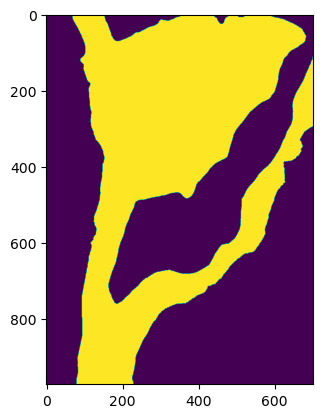

In [36]:
# get the IIDOMAIN array; in our case we only have one layer
ib = gwf.dis.idomain.array[0]
plt.imshow(ib)    

Unique values: [1. 2. 3. 4. 5.]


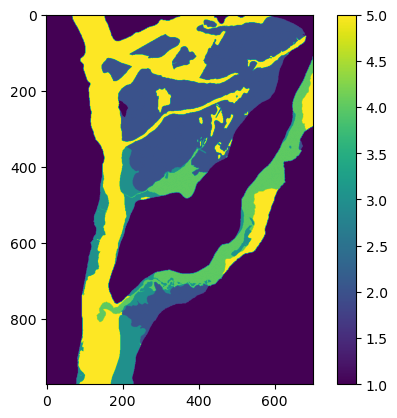

In [37]:
zones_matrix = np.loadtxt(os.path.join('..', 'peterson_template_tran','data-files','rchZones.dat'))
#zones = np.where(np.isin(zones_matrix, [2, 3,4,5]), zones_matrix, 0)
zones= np.where(ib == 1, zones_matrix, 1)
unique_values = np.unique(zones)  # Get unique values
print("Unique values:", unique_values)
np.savetxt('../input-files/data-files/zones.dat', zones, fmt='%.6f', delimiter=' ')
plt.imshow(zones)
plt.colorbar()

In [38]:
# with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
#     values = [line.strip().split() for line in f.readlines()]

# # Specify a new file name for the output
# template_filename = '../peterson_template_tran/data-files/flow-kfield.dat.tpl'

# # Write the PEST++ template to the new file
# with open(template_filename, 'w', encoding='utf-8') as tpl:
#     tpl.write("ptf ~\n")  # Start the template file with ptf~

#     for line in values:
#         tpl_line = []
#         for val in line:
#             # Check if the value is "0" and keep it as "0"
#             if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
#                 tpl_line.append('0')
#             else:
#                 try:
#                     # If the value is not "0", try to convert it to an integer
#                     param_number = int(float(val))  # Convert to float first for scientific notation
#                     # Only replace if the value is not zero
#                     if param_number != 0:
#                         tpl_line.append(f"~hydraulic_cond{param_number}~")
#                     else:
#                         tpl_line.append('0')
#                 except ValueError:
#                     # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
#                     tpl_line.append(f"~hk_invalid~")  # Or another placeholder you prefer
#         tpl.write(' '.join(tpl_line) + '\n')

In [39]:
# with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
#     values = [line.strip().split() for line in f.readlines()]

# # Specify a new file name for the output
# template_filename = '../peterson_template_tran/data-files/rchMult.dat.tpl'

# # Write the PEST++ template to the new file
# with open(template_filename, 'w', encoding='utf-8') as tpl:
#     tpl.write("ptf ~\n")  # Start the template file with ptf~

#     for line in values:
#         tpl_line = []
#         for val in line:
#             # Check if the value is "0" and keep it as "0"
#             if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
#                 tpl_line.append('0')
#             else:
#                 try:
#                     # If the value is not "0", try to convert it to an integer
#                     param_number = int(float(val))  # Convert to float first for scientific notation
#                     # Only replace if the value is not zero
#                     if param_number != 0:
#                         tpl_line.append(f"~rch{param_number}~")
#                     else:
#                         tpl_line.append('0')
#                 except ValueError:
#                     # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
#                     tpl_line.append(f"~rch_invalid~")  # Or another placeholder you prefer
#         tpl.write(' '.join(tpl_line) + '\n')

## Kd TPL

In [40]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-kd-pfos.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~pfos_kd{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~kd_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

In [41]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-kd-pfoa.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~pfoa_kd{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~kd_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

In [42]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-kd-pfhxs.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~pfhxs_kd{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~kd_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

## Porosity TPL

In [43]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-porosity.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~theta{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~theta_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

## Immobile Porosity TPL

In [44]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-immobile-porosity.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~thetaim{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~thetaim_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

## Bulk Density TPL

In [45]:
with open('../peterson_template_tran/data-files/zones.dat', 'r') as f:
    values = [line.strip().split() for line in f.readlines()]

# Specify a new file name for the output
template_filename = '../peterson_template_tran/data-files/tran-bulk-density.dat.tpl'

# Write the PEST++ template to the new file
with open(template_filename, 'w', encoding='utf-8') as tpl:
    tpl.write("ptf ~\n")  # Start the template file with ptf~

    for line in values:
        tpl_line = []
        for val in line:
            # Check if the value is "0" and keep it as "0"
            if val == '0' or val == '0.0' or val.lower() == '0.000000000000000000e+00':
                tpl_line.append('0')
            else:
                try:
                    # If the value is not "0", try to convert it to an integer
                    param_number = int(float(val))  # Convert to float first for scientific notation
                    # Only replace if the value is not zero
                    if param_number != 0:
                        tpl_line.append(f"~rhob{param_number}~")
                    else:
                        tpl_line.append('0')
                except ValueError:
                    # If conversion fails, handle the value (e.g., skip it or use a default placeholder)
                    tpl_line.append(f"~rhob_invalid~")  # Or another placeholder you prefer
        tpl.write(' '.join(tpl_line) + '\n')

## CNC multiplier

In [46]:
def replace_cnc_values(file_path, replacements, new_file_path):
    # Read the original file's contents
    with open(file_path, 'r') as file:
        file_contents = file.read()

    # Replace the values in the replacements dictionary
    for old_text, new_text in replacements.items():
        file_contents = file_contents.replace(old_text, new_text)

    # Add "ptf ~" at the beginning
    updated_contents = "ptf ~\n" + file_contents
    
    # Save the updated contents to a new file
    with open(new_file_path, 'w') as new_file:
        new_file.write(updated_contents)


In [47]:
# Example usage
input_cnc_pfos = '../peterson_template_tran/peterson_pfos.cnc'
input_cnc_pfoa = '../peterson_template_tran/peterson_pfoa.cnc'
input_cnc_pfhxs = '../peterson_template_tran/peterson_pfhxs.cnc'

output_cnc_pfos= '../peterson_template_tran/peterson_pfos.cnc.tpl'
output_cnc_pfoa= '../peterson_template_tran/peterson_pfoa.cnc.tpl'
output_cnc_pfhxs= '../peterson_template_tran/peterson_pfhxs.cnc.tpl'

replacements_pfos = {
    '0.01422620':     '~mult1_pfos~',
    '0.04653590':     '~mult2_pfos~',
    '2.33489000E-04': '~mult3_pfos~',
    '5.07888000E-04': '~mult4_pfos~',
    '2.00000000E-05': '~mult5_pfos~',
    '1.00000000E-05': '~mult6_pfos~'
    
}
replacements_pfoa = {
    '0.01422620':     '~mult1_pfoa~',
    '0.04653590':     '~mult2_pfoa~',
    '2.33489000E-04': '~mult3_pfoa~',
    '5.07888000E-04': '~mult4_pfoa~',
    '2.00000000E-05': '~mult5_pfoa~',
    '1.00000000E-05': '~mult6_pfoa~'
    
}
replacements_pfhxs = {
    '0.01422620':     '~mult1_pfhxs~',
    '0.04653590':     '~mult2_pfhxs~',
    '2.33489000E-04': '~mult3_pfhxs~',
    '5.07888000E-04': '~mult4_pfhxs~',
    '2.00000000E-05': '~mult5_pfhxs~',
    '1.00000000E-05': '~mult6_pfhxs~'
    
}
replace_cnc_values(input_cnc_pfos, replacements_pfos, output_cnc_pfos)
replace_cnc_values(input_cnc_pfoa, replacements_pfoa, output_cnc_pfoa)
replace_cnc_values(input_cnc_pfhxs, replacements_pfhxs, output_cnc_pfhxs)


In [48]:
[f for f in os.listdir('../peterson_template_tran/data-files') if f.endswith(".tpl")]

['tran-bulk-density.dat.tpl',
 'tran-immobile-porosity.dat.tpl',
 'tran-kd-pfhxs.dat.tpl',
 'tran-kd-pfoa.dat.tpl',
 'tran-kd-pfos.dat.tpl',
 'tran-porosity.dat.tpl']

In [49]:
[f for f in os.listdir('../peterson_template_tran') if f.endswith(".tpl")]

['peterson_pfhxs.cnc.tpl', 'peterson_pfoa.cnc.tpl', 'peterson_pfos.cnc.tpl']

### Write External TPL .csv files to reference in PEST control file

In [50]:
# Get all .tpl files in data-files directory
data_files = [f"data-files/{f}" for f in os.listdir('../peterson_template_tran/data-files') if f.endswith(".tpl")]

# Get all .tpl files in the main directory
main_files = [f for f in os.listdir('../peterson_template_tran') if f.endswith(".tpl")]

#combine into one list
all_tpl_files = data_files + main_files

#get all corresponding model files
model_files = [f.replace('.tpl', '') for f in all_tpl_files]

In [51]:
tpl_data = pd.DataFrame({
    'pest_file': all_tpl_files,
    'model_file': model_files
})

tpl_data=pd.DataFrame(tpl_data)

In [52]:
tpl_data=tpl_data.astype(str)
tpl_data.to_csv('../peterson_template_tran/peterson_tran.tplfile_data.csv', index=False)

### Write External Parameter .csv files to reference in PEST control file

In [53]:
def build_param_group_df(param_groups, inctyp_vals, derinc_vals, derinclb_vals, forcen_vals, derincmul_vals, dermthd_vals, splitthresh_vals, splitaction_vals, n_vals):
    """
    Build a DataFrame with the same structure for multiple parameter groups.
    
    Parameters:
    - param_groups: List of parameter group names (zones)
    - inctyp_vals, derinc_vals, derinclb_vals, forcen_vals, derincmul_vals, dermthd_vals, splitthresh_vals, splitaction_vals: 
      Lists with values to be repeated for each parameter group
    
    Returns:
    - DataFrame with rows for each parameter group
    """
    data = {
        'pargpnme': [],
        'inctyp': [],
        'derinc': [],
        'derinclb': [],
        'forcen': [],
        'derincmul': [],
        'dermthd': [],
        'splitthresh': [],
        'splitaction': [],
        'n':[]
    }
    
    for group in param_groups:
        for i in range(len(inctyp_vals)):  # Assuming all lists have the same length
            data['pargpnme'].append(group)
            data['inctyp'].append(inctyp_vals[i])
            data['derinc'].append(derinc_vals[i])
            data['derinclb'].append(derinclb_vals[i])
            data['forcen'].append(forcen_vals[i])
            data['derincmul'].append(derincmul_vals[i])
            data['dermthd'].append(dermthd_vals[i])
            data['splitthresh'].append(splitthresh_vals[i])
            data['splitaction'].append(splitaction_vals[i])
            data['n'].append(n_vals[i])
    
    return pd.DataFrame(data)

In [54]:
param_groups = ['porosity','immobile-porosity','bulk-density','conc', 'pfos_kd','pfoa_kd','pfhxs_kd', 'hk', 'rch']
# Define the values that should be repeated for each group
inctyp_vals = ['relative']  # Example values for 'inctyp'
derinc_vals = [0.01]
derinclb_vals = [0]
forcen_vals = ['switch']
derincmul_vals = [2]
dermthd_vals = ['parabolic']
splitthresh_vals = [0.00001]
splitaction_vals = [0.5]
n_vals= ['smaller']

# Build the DataFrame
pargp_df = build_param_group_df(param_groups, inctyp_vals, derinc_vals, derinclb_vals, forcen_vals, derincmul_vals, dermthd_vals, splitthresh_vals, splitaction_vals,n_vals)

In [55]:
# Save the DataFrame to a CSV file
output_filename = '../peterson_template_tran/peterson_tran.pargp_data.csv'
pargp_df=pargp_df.astype(str)
pargp_df.to_csv(output_filename, index=False)

In [56]:
def build_param_df(param_names, partrans, parchglim, parval1, parlbnd, parubnd, pargp, scale, offset, dercom):
    """
    Build a DataFrame with customized parameter values and export it to a CSV for PEST++.

    Parameters:
    - param_names: List of parameter names
    - partrans: List of transformation types for each parameter
    - parchglim: List of change limits for each parameter
    - parval1: List of initial values for each parameter
    - parlbnd: List of lower bounds for each parameter
    - parubnd: List of upper bounds for each parameter
    - pargp: List of parameter groups (zones)
    - scale: List of scale factors for each parameter
    - offset: List of offsets for each parameter
    - dercom: List of derivative computation flags for each parameter

    Returns:
    - DataFrame with rows for each parameter group and exported as a CSV file
    """
    
    # Creating the data dictionary for the DataFrame
    data = {
        'parnme': param_names,
        'partrans': partrans,
        'parchglim': parchglim,
        'parval1': parval1,
        'parlbnd': parlbnd,
        'parubnd': parubnd,
        'pargp': pargp,
        'scale': scale,
        'offset': offset,
        'dercom': dercom
    }
    # Creating the DataFrame
    param_df = pd.DataFrame(data)

    # Exporting to CSV for PEST++
    param_df=param_df.astype(str)
    param_df.to_csv('../peterson_template_tran/peterson_tran.par_data.csv', index=False)

    return param_df

In [57]:
def generate_param_names(prefix, count):
    return [f'{prefix}{i+1}' for i in range(count)]
    
def generate_param_names_cnc(prefix, suffix, count):
    return [f'{prefix}{i+1}{suffix}' for i in range(count)]

#transport parameters
param_names_conc =  generate_param_names_cnc('mult', '_pfos', 6) + generate_param_names_cnc('mult','_pfoa', 6) + generate_param_names_cnc('mult','_pfhxs', 6)
param_names_por=  generate_param_names('theta', 5)
param_names_porim=  generate_param_names('thetaim', 5)
param_names_bulkd=  generate_param_names('rhob', 5)

param_names_kd_pfos=  generate_param_names('pfos_kd', 5)
param_names_kd_pfoa=  generate_param_names('pfoa_kd', 5)
param_names_kd_pfhxs=  generate_param_names('pfhxs_kd', 5)

# #flow parameters 
# param_names_rch = generate_param_names('rch', 5)
# param_names_hk = generate_param_names('hydraulic_cond', 5)

param_names =  param_names_conc + param_names_por +param_names_porim + param_names_bulkd + param_names_kd_pfos + param_names_kd_pfoa + param_names_kd_pfhxs 

#+ param_names_rch + param_names_hk

# Assign specific bounds for parameters

#concentration multiplier
parlbnd_conc = [0.0000001] * 18
parubnd_conc = [1000] * 18

#porosity
parlbnd_por = [0.005] * 5
parubnd_por = [0.5] * 5

#immobile porosity
parlbnd_porim = [0.0005] * 5
parubnd_porim = [0.5] * 5

#bulk density
parlbnd_bulkd = [1300] * 5
parubnd_bulkd = [2500] * 5

#kd
parlbnd_kd_pfos =  [10 ** (-8)] * 5
parlbnd_kd_pfoa= [10 ** (-8)] * 5
parlbnd_kd_pfhxs=[10 ** (-8)] * 5

parubnd_kd_pfos =  [10 ** (-1.3)] * 5
parubnd_kd_pfoa= [10 ** (-1.8)] * 5
parubnd_kd_pfhxs=[10 ** (-2.2)] * 5

# # rch
# parlbnd_rch = [1e-6] * 5
# parubnd_rch = [0.5] * 5

# #hk
# parlbnd_hk = [1.00000000e-02] *5   
# parubnd_hk = [400] * 5 

# Combine the bounds
parlbnd = parlbnd_conc + parlbnd_por +parlbnd_porim + parlbnd_bulkd + parlbnd_kd_pfos +parlbnd_kd_pfoa +parlbnd_kd_pfhxs 
#+ parlbnd_rch + parlbnd_hk

parubnd = parubnd_conc + parubnd_por +parubnd_porim + parubnd_bulkd + parubnd_kd_pfos +parubnd_kd_pfoa +parubnd_kd_pfhxs 
#+ parubnd_rch + parubnd_hk

# Assign intial values
parval1_conc= [0.0602532, 0.0233345, 0.00777345, 1.69117, 0.00002, 0.00001] * 3
parval1_por= [0.0873818, 0.322898, 0.353187, 0.259206, 0.228821]
parval1_porim= [0.0867503, 0.0759499, 0.435497, 0.11082, 0.0344326]
parval1_bulkd= [2490.42, 1790.06, 1896.02, 1679.45, 2227.6]

parval1_kd_pfos =  [2.754e-06, 2.754e-05, 0.002754, 2.754e-05, 2.754e-06]
parval1_kd_pfoa= [1.148e-06, 1.148e-05, 0.001148, 1.148e-05, 1.148e-06] 
parval1_kd_pfhxs=[6.0256e-07, 6.0256e-06, 0.00060256, 6.0256e-06, 6.0256e-07]

# parval1_rch = [0.1] * 5
# parval1_hk = [1.00000000e-02, 36.70163300000, 23.03195400000, 43.63568700000, 122.1909600000]

# Combine the parameter values
parval1 =  parval1_conc + parval1_por +parval1_porim + parval1_bulkd + parval1_kd_pfos +parval1_kd_pfoa +parval1_kd_pfhxs 
#+ parval1_rch + parval1_hk

# Other parameter attributes
partrans = ['log'] * len(param_names)
parchglim = ['factor'] * len(param_names)
pargp =  ['conc'] * 18 + ['porosity'] * 5 + ['immobile-porosity'] * 5 + ['bulk-density'] * 5  + ['kd_pfos'] * 5 + ['kd_pfoa'] * 5 + ['kd_pfhxs'] * 5 
#+ ['rch'] * 5 + ['hk'] * 5

#scaLe parameters so they are the same magnitude, order: conc, por, porim, bulkd, kd, rch, hk
scale =  [1] *18+ [1] *10 +[10e-5]*5 + [10000] *15 
#+ [0.01]*5 + [0.001] * 5

offset = [0] * len(param_names)
dercom = [1] * len(param_names)

param_df = build_param_df(param_names, partrans, parchglim, parval1, parlbnd, parubnd, pargp, scale, offset, dercom)
param_df

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom
0,mult1_pfos,log,factor,0.0602532,1e-07,1000.0,conc,1.0,0,1
1,mult2_pfos,log,factor,0.0233345,1e-07,1000.0,conc,1.0,0,1
2,mult3_pfos,log,factor,0.00777345,1e-07,1000.0,conc,1.0,0,1
3,mult4_pfos,log,factor,1.69117,1e-07,1000.0,conc,1.0,0,1
4,mult5_pfos,log,factor,2e-05,1e-07,1000.0,conc,1.0,0,1
5,mult6_pfos,log,factor,1e-05,1e-07,1000.0,conc,1.0,0,1
6,mult1_pfoa,log,factor,0.0602532,1e-07,1000.0,conc,1.0,0,1
7,mult2_pfoa,log,factor,0.0233345,1e-07,1000.0,conc,1.0,0,1
8,mult3_pfoa,log,factor,0.00777345,1e-07,1000.0,conc,1.0,0,1
9,mult4_pfoa,log,factor,1.69117,1e-07,1000.0,conc,1.0,0,1


In [58]:
def write_pest_version2_control_file(file_path, parameter_group_file, parameter_file, observation_file_1, observation_file_2, observation_file_3, model_command, input_file, output_file):
    with open(file_path, 'w', encoding='utf-8') as f:
        # Header with version 2
        f.write("pcf version=2\n")

        # Control data section
        f.write("* control data keyword\n")
        f.write("pestmode                                 estimation\n")
        f.write("noptmax                                 10\n")
        f.write("svdmode                                 1\n")
        f.write("maxsing                                  10000000\n")
        f.write("eigthresh                               1e-06\n")
        f.write("eigwrite                                1\n")
        # f.write("ies_bad_phi_sigma                       2.5\n")
        # f.write("ies_autoadaloc                          True\n")
        # f.write("ies_parameter_ensemble                  ../peterson_template_tran/peterson_tran.prior.par.csv\n")
        # f.write("ies_observation_ensemble                ../peterson_template_tran/peterson_tran.prior.obs+noise.csv\n")
        f.write("ies_num_reals                           100\n")
        # f.write("ies_num_threads                         14\n")
        
        # Parameter groups section
        f.write("* parameter groups external\n")
        f.write(f"{parameter_group_file}\n")

        # Parameter data section
        f.write("* parameter data external\n")
        f.write(f"{parameter_file}\n")

        # Observation data section
        f.write("* observation data external\n")
        f.write(f"{observation_file_1}\n")
        f.write(f"{observation_file_2}\n")
        f.write(f"{observation_file_3}\n")

        # Model command line
        f.write("* model command line\n")
        f.write(f"{model_command}\n")

        # Model input file section
        f.write("* model input external\n")
        f.write(f"{input_file}\n")

        # Model output file section
        f.write("* model output external\n")
        f.write(f"{output_file}\n")

In [59]:
# Example usage
write_pest_version2_control_file(
    "../peterson_template_tran/peterson_tran.pst",
    "peterson_tran.pargp_data.csv",
    "peterson_tran.par_data.csv",
    "peterson_pfos.obs_data.csv",
    "peterson_pfoa.obs_data.csv",
    "peterson_pfhxs.obs_data.csv",
    "python forward_run_tran.py",
    "peterson_tran.tplfile_data.csv",
    "peterson_tran.insfile_data.csv"
)

In [60]:
shutil.copy('forward_run_tran.py', template_ws)

'..\\peterson_template_tran\\forward_run_tran.py'

In [67]:
shutil.copy('../bin/mf6.exe', template_ws)

'..\\peterson_template_tran\\mf6.exe'

In [68]:
shutil.copy('../bin/pestpp-glm.exe', template_ws)

'..\\peterson_template_tran\\pestpp-glm.exe'

In [69]:
shutil.copy('../bin/pestpp-ies.exe', template_ws)

'..\\peterson_template_tran\\pestpp-ies.exe'

In [72]:
# Define the path to your PEST++ executable
pest_exe = "pestpp-glm"

# Define the path to your control file
control_file = "peterson_tran.pst"

# Define the working directory where PEST++ should run
working_dir = template_ws
#t_d = template_ws

# Specify the number of agents (cores) you want to use
num_workers = 6 #psutil.cpu_count(logical=False)

#m_d = os.path.join('../master_glm_1')

In [ ]:
# Run PEST++ GLM with subprocess, setting the working directory
subprocess.run([pest_exe, control_file], cwd=working_dir, check=True)

In [11]:
import os_utils

In [ ]:
os_utils.start_workers(
    template_ws,
    'pestpp-ies',
    'peterson_tran.pst',
    num_workers=num_workers,
    worker_root='..',
    master_dir='../ies'
)

In [1]:
# Run PEST++ GLM with subprocess, setting the working directory
# subprocess.run([pest_exe, control_file], cwd=working_dir, check=True)

In [25]:
import subprocess

# Run jacobian_summary using subprocess
try:
    result = subprocess.run(['jacobian_summary', '../build_prior/peterson_tran.jcb'], capture_output=True, text=True, check=True)
    print(result.stdout)  # Prints the jacobian summary
except subprocess.CalledProcessError as e:
    print(f"Error while running jacobian_summary: {e}")


FileNotFoundError: [WinError 2] The system cannot find the file specified

### Explore the Outcomes

`pestpp-swp` writes the results of the the prior Monte Carlo to a csv file called `freyberg_mf6.0.obs.csv`. Note the naming convention - this is the base `pst` file name (`freyberg_mf6`) followed by the iteration number (`0` indicating this is at the beginning of the process - e.g. _prior_ Monte Carlo) and `.obs.csv` indicating this file contains observation values. This file has columns for each observation listed in the control file, plus an index column with the realization name. 


In [14]:
obs_df = pd.read_csv(os.path.join(template_ws,"peterson_tran.0.obs.csv"),index_col=0)
print('number of realizations in the ensemble: ' + str(obs_df.shape[0]))

number of realizations in the ensemble: 50


In [15]:
phi_df = pd.read_csv(os.path.join(template_ws,"peterson_tran.phi.actual.csv"),index_col=0)
phi_df

,total_runs,mean,standard_deviation,min,max,0,1,2,3,4,...,40,41,42,43,44,45,46,47,48,base
iteration,,,,,,,,,,,,,,,,,,,,,
0,50,0.009179,0.018666,6.174890e-10,0.089045,0.001936,0.000032,0.000121,6.174890e-10,0.002422,...,1.517940e-07,0.089045,0.004118,0.002321,0.006333,0.042603,0.033877,0.003339,3.670120e-07,0.000005


<Axes: >

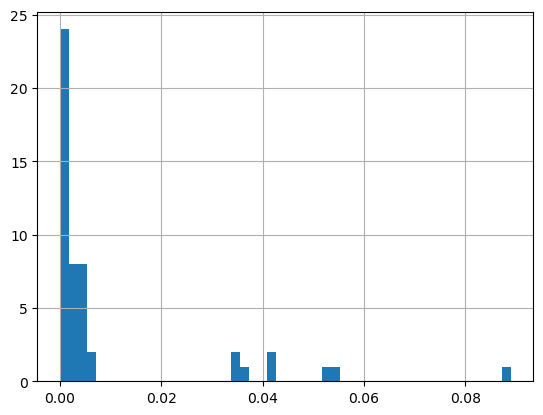

In [16]:
phi_df = phi_df.T.iloc[5:].rename(columns={0:'phi'})
phi_df.phi.hist(bins=50)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load the prior Monte Carlo parameter ensemble
par_file = "../peterson_template_tran/peterson_tran.0.par.csv"  # Update with your actual file name
df = pd.read_csv(par_file, index_col=0)

In [25]:
# Drop non-numeric columns if needed (like realization index)
df = df.select_dtypes(include=["float64", "int64"])

# Set Seaborn style
sns.set_style("whitegrid")

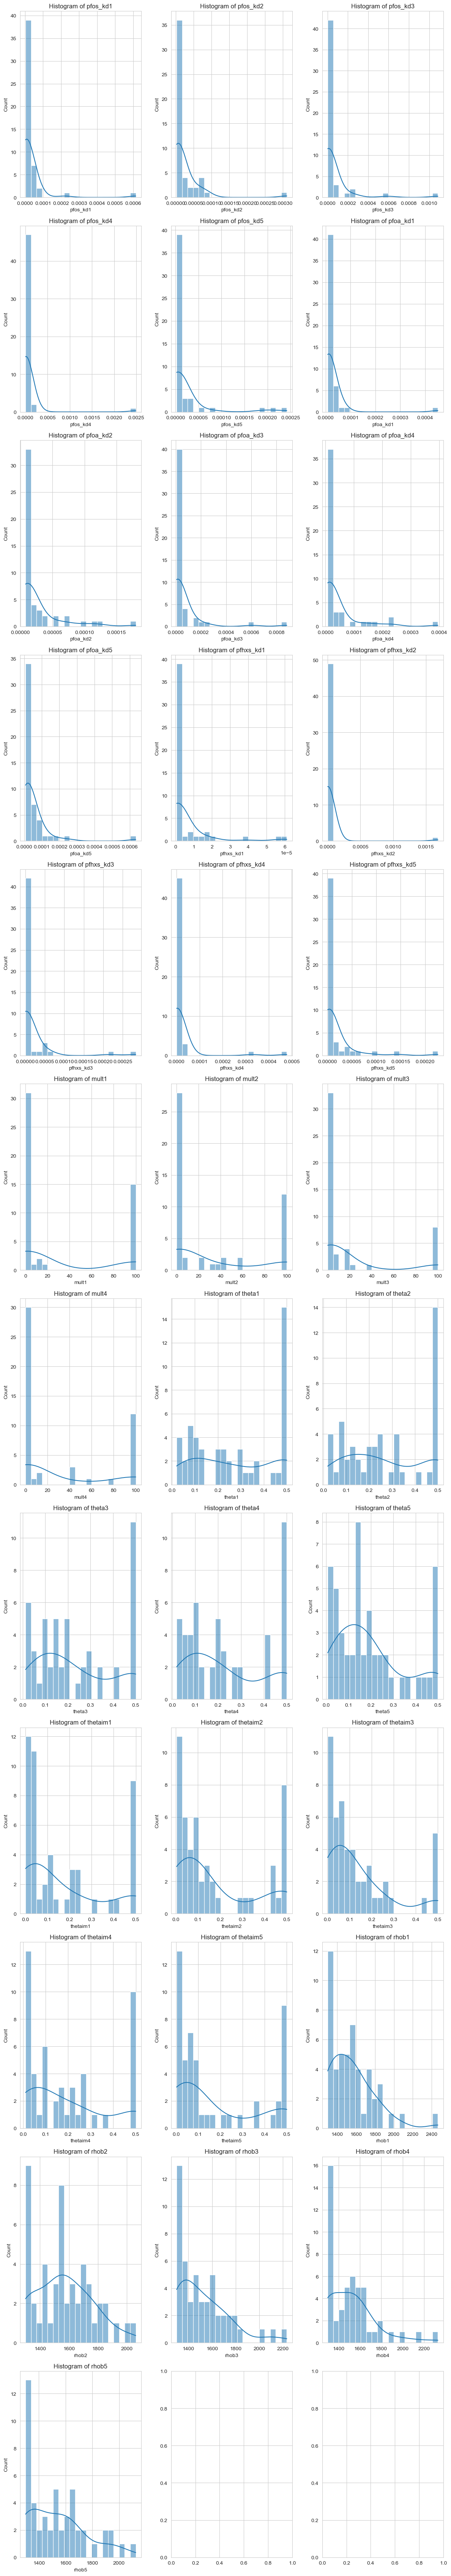

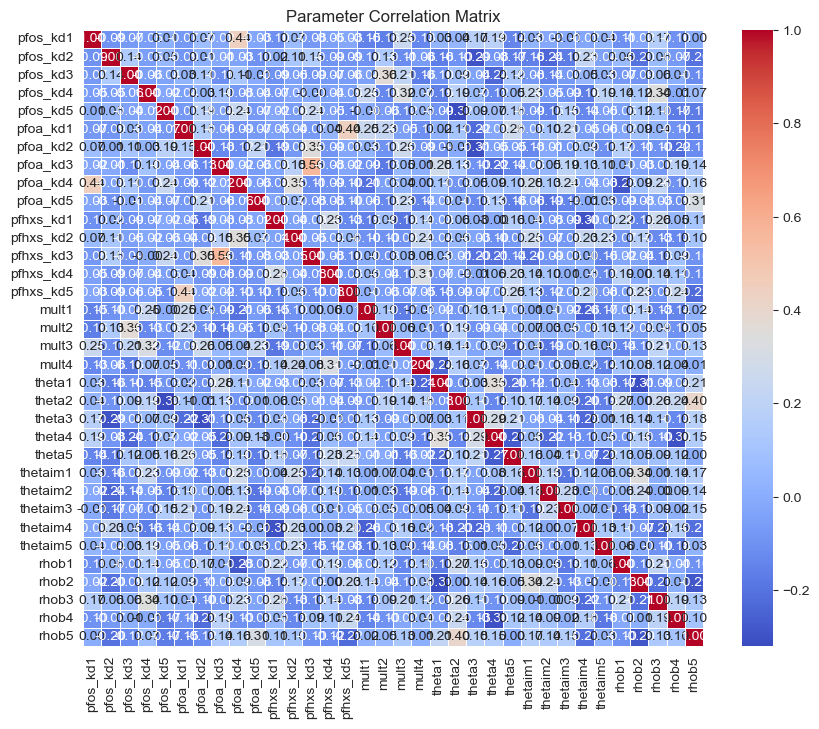

In [26]:
# --- 1. Plot Histograms of Parameter Distributions ---
def plot_histograms(df):
    num_params = df.shape[1]
    fig, axes = plt.subplots(nrows=num_params//3 + 1, ncols=3, figsize=(12, num_params * 2))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        sns.histplot(df[col], kde=True, ax=axes[i], bins=20)
        axes[i].set_title(f"Histogram of {col}")

    plt.tight_layout()
    plt.show()

plot_histograms(df)

# --- 2. Correlation Matrix Heatmap ---
def plot_correlation_matrix(df):
    plt.figure(figsize=(10, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Parameter Correlation Matrix")
    plt.show()

plot_correlation_matrix(df)

# --- 3. Pairwise Scatter Plots ---
def plot_scatter_matrix(df, sample_size=100):
    """Plots scatter plots for the first 6 parameters (or fewer if available)."""
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)  # Sample for better visualization
    sns.pairplot(sample_df)
    plt.suptitle("Pairwise Scatter Plots", y=1.02)
    plt.show()

plot_scatter_matrix(df)

In [ ]:
# # Start the PESTPP manager on a designated port (e.g., 4000)
# subprocess.run([pest_exe, control_file, "/h", ":4001"], cwd=working_dir, check=True)